In [19]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain.messages import RemoveMessage

In [20]:
load_dotenv()

True

In [21]:
model = ChatNVIDIA(model = 'openai/gpt-oss-20b')

In [ ]:
def chat(state: MessagesState):
    response = model.invoke(state['messages'])
    
    return {'messages':[response]}

def delete_old_messages(state: MessagesState):
    msgs = state['messages']
    
    # If more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {'messages':[RemoveMessage(id = m.id) for m in to_remove]}
    
    return {}

In [23]:
builder = StateGraph(MessagesState)
builder.add_node('chat',chat)
builder.add_node('cleanup',delete_old_messages)

builder.add_edge(START,'chat')
builder.add_edge('chat','cleanup')
builder.add_edge('cleanup','__end__')

In [24]:
graph = builder.compile(checkpointer = InMemorySaver())

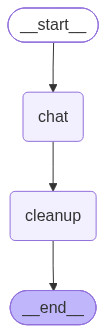

In [25]:
graph

In [26]:
config = {'configurable':{'thread_id':'t1'}}

In [27]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Saurabh"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='59703c2f-f890-4d69-badb-5b6c56f0dba1'),
  AIMessage(content='## 📚 What is LangChain?\n\nLangChain is **the most widely‑used Python (and JavaScript) framework for building applications that *think* with large language models**.  \nIt standardizes and simplifies connecting LLMs to the rest of your stack—retrieval, APIs, tools, databases, memory, and more—so you can focus on the *logic* of your app rather than plumbing.\n\n---\n\n### 1. Short Origin Story\n\n| Year | Milestone |\n|------|-----------|\n| **2021** | *LlamaIndex* (now called **LangChain**) is founded by McKinsey‑ML member **Michael Wu** to make building LLM‑powered knowledge‑base apps painless. |\n| **2022** | The project rebrands as **LangChain**, emphasizing the *language*-centric programming paradigm. |\n| **2023‑24** | LangChain evolves into a large, modular ecosystem, adding `langgraph`, conversational memory, agents,